In [1]:
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

drive.mount('/content/drive')

processed_data_path = "/content/drive/MyDrive/diabetes_processed_tensors.pt"
data_dict = torch.load(processed_data_path)

# Unpack into individual variables (train, validation and test)
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

print("Tensors loaded successfully!")
print(f"Train features: {X_train.shape} | Train labels: {y_train.shape}")
print(f"Val features:   {X_val.shape}   | Val labels:   {y_val.shape}")
print(f"Test features:  {X_test.shape}  | Test labels:  {y_test.shape}")

Mounted at /content/drive
Tensors loaded successfully!
Train features: torch.Size([128074, 12]) | Train labels: torch.Size([128074])
Val features:   torch.Size([14997, 12])   | Val labels:   torch.Size([14997])
Test features:  torch.Size([14998, 12])  | Test labels:  torch.Size([14998])


In [2]:
# Wrapper for tabular tensors

class DiabetesTabularDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        # Unsqueezing changes shape from [N] to [N, 1] to match Sigmoid outputs
        self.labels = labels.unsqueeze(1) if labels.dim() == 1 else labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Instantiate dataset wrappers
train_dataset = DiabetesTabularDataset(X_train, y_train)
val_dataset = DiabetesTabularDataset(X_val, y_val)
test_dataset = DiabetesTabularDataset(X_test, y_test)

# Define DataLoaders
# Shuffle training data to maximize stochastic gradient descent efficacy,
# But keep validation/testing sequential for stable evaluation.
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"DataLoaders ready! Number of training batches: {len(train_loader)}")

DataLoaders ready! Number of training batches: 501


In [3]:
# =====================================================================
# MODEL A: BASELINE MULTI-LAYER PERCEPTRON (MLP)
# =====================================================================
class BaselineMLP(nn.Module):
    """
    Primary baseline reference model. Accepts 12 features and maps them
    through fully connected layers with ReLU activations and a Sigmoid output.
    """
    def __init__(self, input_dim=12):
        super(BaselineMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =====================================================================
# MODEL B: ONE-DIMENSIONAL CONVOLUTIONAL NEURAL NETWORK (1D-CNN)
# =====================================================================
class OneDCNN(nn.Module):
    """
    Architectural contrast model. Treats the 12 tabular features as a
    1D sequence to detect localized feature interaction patterns.
    """
    def __init__(self, input_dim=12):
        super(OneDCNN, self).__init__()
        # In_channels=1 (treating tabular array as a single-channel sequence)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2) # Length 12 becomes 6

        # Fully connected classifier tail
        self.fc = nn.Sequential(
            nn.Linear(16 * 6, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Reshape input from [Batch, Features] to [Batch, Channels, Features]
        # e.g., [256, 12] -> [256, 1, 12]
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten the sequence tensor for the linear layers
        x = x.view(x.size(0), -1)
        return self.fc(x)


# =====================================================================
# MODEL C: ENHANCED ATTENTION-MLP (PHASE 3 UPDATED)
# =====================================================================
class AttentionMLP(nn.Module):
    """
    Enhanced model incorporating a feature-level soft attention layer,
    Batch Normalization, and Dropout regularization.
    Updated for Phase 3: Allows extraction of attention weights for interpretability.
    """
    def __init__(self, input_dim=12):
        super(AttentionMLP, self).__init__()

        # 1. Soft Attention Layer
        self.attention_weights = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

        self.layer1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.3)

        self.layer2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(0.3)

        self.output_layer = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, return_attention=False):
        weights = self.attention_weights(x)
        scaled_x = x * weights

        x1 = self.dropout1(torch.relu(self.bn1(self.layer1(scaled_x))))
        x2 = self.dropout2(torch.relu(self.bn2(self.layer2(x1))))
        out = self.sigmoid(self.output_layer(x2))

        # Phase 3: Return weights alongside predictions if requested
        if return_attention:
            return out, weights
        return out

# Instantiate models to verify initialization
model_a = BaselineMLP()
model_b = OneDCNN()
model_c = AttentionMLP()

print("All three model architectures successfully constructed!")

All three model architectures successfully constructed!


In [4]:
# =====================================================================
# CUSTOM LOSS FUNCTION: FOCAL LOSS
# =====================================================================
class FocalLoss(nn.Module):
    """
    Computes Focal Loss to balance class-level optimization gradients.
    Focuses the backpropagation loop on hard-to-classify diabetic minority examples.
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard binary cross entropy loss per sample
        bce_loss = nn.BCELoss(reduction='none')(inputs, targets)

        # Calculate likelihood probability (pt) of the correct class classification
        pt = torch.exp(-bce_loss)

        # Apply the modulation factor and alpha weight factor
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# =====================================================================
# UNIFIED MODEL TRAINING LOOP ENGINE
# =====================================================================
def train_model(model, criterion, optimizer, scheduler=None, epochs=30, model_name="Model"):
    """
    A single robust runtime pipeline engine to execute training epochs,
    track historic performance loss curves, and apply Early Stopping.
    """
    print(f"Initializing Training Pipeline for: {model_name}")
    print("-" * 50)

    # Trackers for training progression histories
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    early_stop_patience = 5
    patience_counter = 0

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0

        for batch_features, batch_labels in train_loader:
            optimizer.zero_grad()               # Clear existing gradients
            outputs = model(batch_features)     # Forward pass calculation
            loss = criterion(outputs, batch_labels) # Calculate batch loss
            loss.backward()                     # Backpropagate gradients
            optimizer.step()                    # Update network weights

            running_train_loss += loss.item() * batch_features.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)

        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad(): # Disable gradient calculation for efficiency
            for batch_features, batch_labels in val_loader:
                outputs = model(batch_features)
                loss = criterion(outputs, batch_labels)
                running_val_loss += loss.item() * batch_features.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)

        # Append history records for plotting curves later
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        # Handle Adaptive Learning Rate Scheduler adjustments if provided
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # --- EARLY STOPPING & MODEL CHECKPOINTING ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            # Save the model weights to the execution environment path
            torch.save(model.state_dict(), f"best_{model_name.lower()}.pth")
            patience_counter = 0  # Reset patience counter
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping triggered! Training halted at epoch {epoch+1}.")
                break

    print(f"Training completed for {model_name}. Best Validation Loss: {best_val_loss:.4f}")
    return history

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================================
# INTERMEDIATE INITIALIZATION & TRAINING EXECUTION
# =====================================================================

# 1. Initialize Model A (Baseline MLP)
model_a = BaselineMLP(input_dim=12)
criterion_a = nn.BCELoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)

# Execute Training for Model A
history_a = train_model(
    model=model_a,
    criterion=criterion_a,
    optimizer=optimizer_a,
    scheduler=None,
    epochs=30,
    model_name="Baseline_MLP"
)

# ---------------------------------------------------------------------

# 2. Initialize Model B (1D-CNN)
model_b = OneDCNN(input_dim=12)
criterion_b = nn.BCELoss()
optimizer_b = optim.Adam(model_b.parameters(), lr=0.001)

# Execute Training for Model B
history_b = train_model(
    model=model_b,
    criterion=criterion_b,
    optimizer=optimizer_b,
    scheduler=None,
    epochs=30,
    model_name="1D_CNN"
)

# ---------------------------------------------------------------------

# 3. Initialize Model C (Enhanced Attention-MLP)
model_c = AttentionMLP(input_dim=12)
# Alpha=0.25 and Gamma=2.0 are standard baseline hyperparameters for Focal Loss
criterion_c = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean')
optimizer_c = optim.Adam(model_c.parameters(), lr=0.001)

# Reduce learning rate by half (factor=0.5) if validation loss fails to improve for 2 epochs
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_c,
    mode='min',
    patience=2,
    factor=0.5
)

# Execute Training for Model C
history_c = train_model(
    model=model_c,
    criterion=criterion_c,
    optimizer=optimizer_c,
    scheduler=scheduler_c,
    epochs=30,
    model_name="Attention_MLP"
)

Initializing Training Pipeline for: Baseline_MLP
--------------------------------------------------
Epoch 01/30 | Train Loss: 0.2769 | Val Loss: 0.2304
Epoch 02/30 | Train Loss: 0.2129 | Val Loss: 0.1955
Epoch 03/30 | Train Loss: 0.1998 | Val Loss: 0.2046
Epoch 04/30 | Train Loss: 0.1914 | Val Loss: 0.2003
Epoch 05/30 | Train Loss: 0.1853 | Val Loss: 0.1881
Epoch 06/30 | Train Loss: 0.1806 | Val Loss: 0.1991
Epoch 07/30 | Train Loss: 0.1774 | Val Loss: 0.1463
Epoch 08/30 | Train Loss: 0.1744 | Val Loss: 0.1807
Epoch 09/30 | Train Loss: 0.1720 | Val Loss: 0.1777
Epoch 10/30 | Train Loss: 0.1707 | Val Loss: 0.1923
Epoch 11/30 | Train Loss: 0.1693 | Val Loss: 0.1889
Epoch 12/30 | Train Loss: 0.1678 | Val Loss: 0.1502
Early stopping triggered! Training halted at epoch 12.
Training completed for Baseline_MLP. Best Validation Loss: 0.1463
Initializing Training Pipeline for: 1D_CNN
--------------------------------------------------
Epoch 01/30 | Train Loss: 0.2792 | Val Loss: 0.2259
Epoch 02/


================ Model A: Baseline MLP Final Test Evaluation ================
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.94      0.96     13723
    Diabetic       0.55      0.85      0.67      1275

    accuracy                           0.93     14998
   macro avg       0.77      0.89      0.82     14998
weighted avg       0.95      0.93      0.94     14998


================ Model B: 1D-CNN Final Test Evaluation ================
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.92      0.95     13723
    Diabetic       0.50      0.88      0.64      1275

    accuracy                           0.92     14998
   macro avg       0.75      0.90      0.80     14998
weighted avg       0.95      0.92      0.93     14998


================ Model C: Attention-MLP Final Test Evaluation ================
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.90      0.94     13723
    D

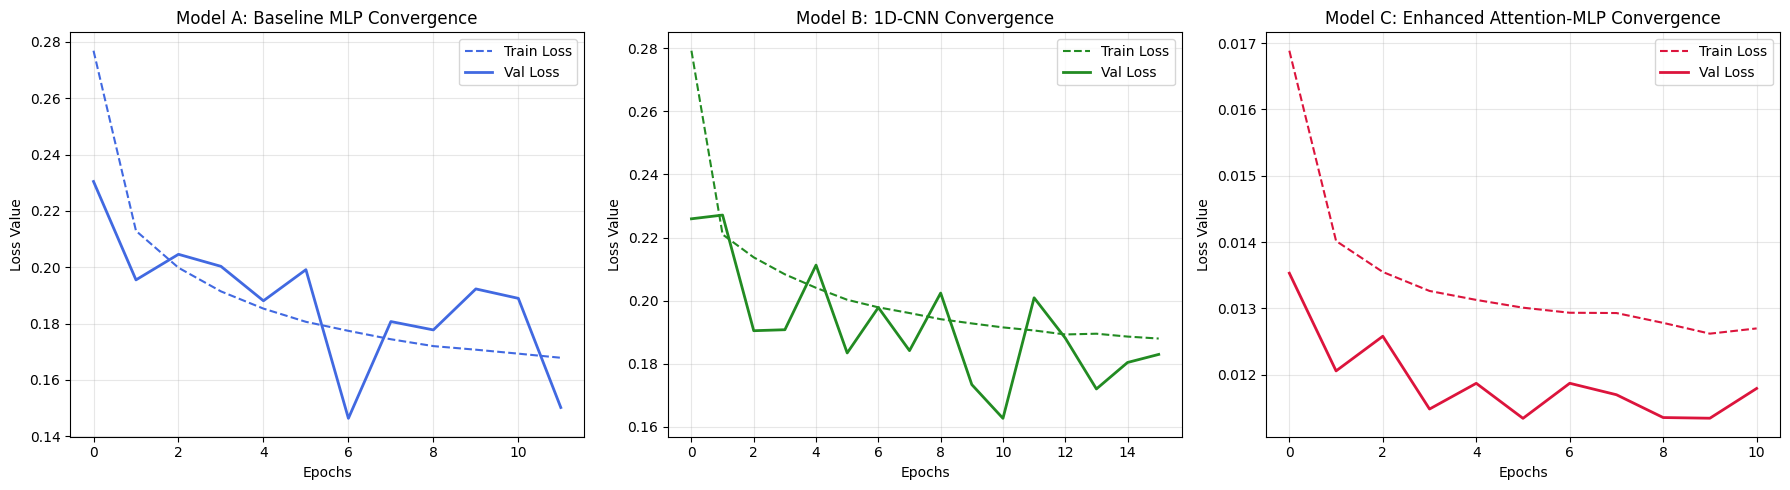

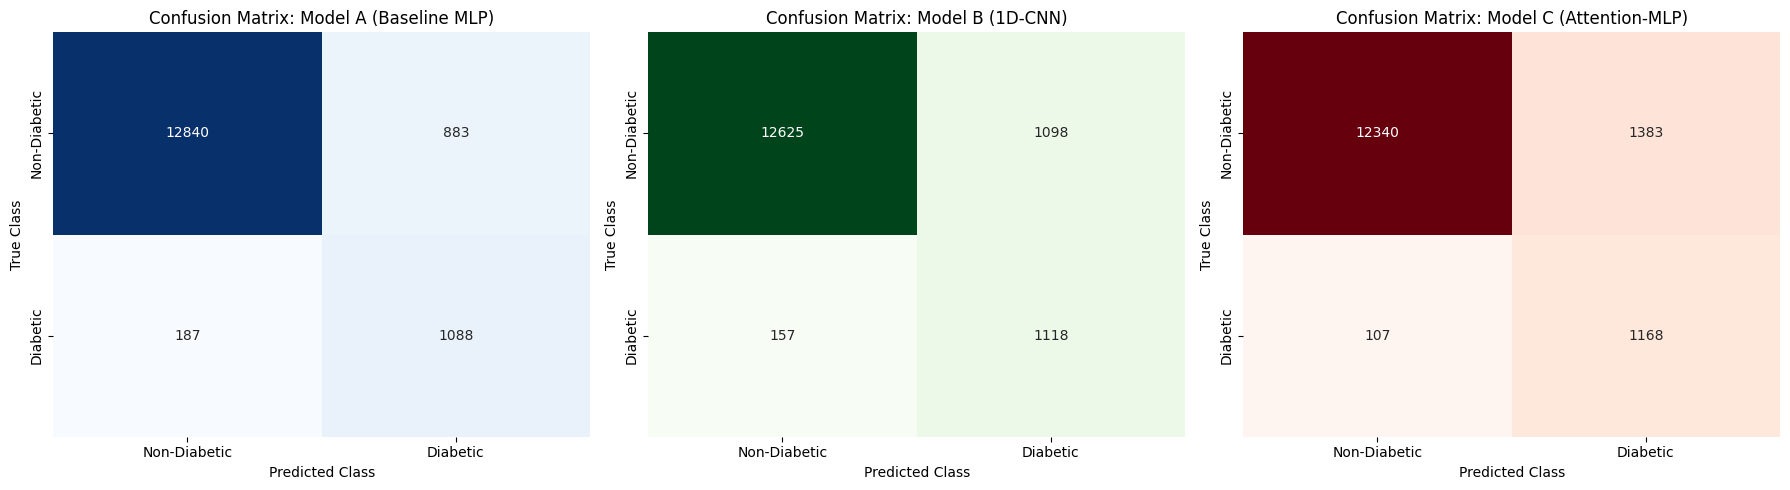

In [6]:
# =====================================================================
# EVALUATE MODEL ON TEST SET
# =====================================================================
def evaluate_test_set(model, weight_path, model_name="Model"):
    """
    Loads the best checkpointed weights, runs predictions on the test loader,
    and returns the true labels, binary predictions, and raw classification metrics.
    """
    # Load optimal saved parameters from the local directory
    model.load_state_dict(torch.load(weight_path))
    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            outputs = model(batch_features)
            # Apply a standard classification threshold of 0.5
            preds = (outputs >= 0.5).float()

            test_preds.extend(preds.numpy())
            test_targets.extend(batch_labels.numpy())

    test_targets = np.array(test_targets)
    test_preds = np.array(test_preds)

    print(f"\n================ {model_name} Final Test Evaluation ================")
    print(classification_report(test_targets, test_preds, target_names=['Non-Diabetic', 'Diabetic']))

    return test_targets, test_preds

# Execute evaluations and collect arrays for visual plots
y_true_a, y_pred_a = evaluate_test_set(model_a, "best_baseline_mlp.pth", "Model A: Baseline MLP")
y_true_b, y_pred_b = evaluate_test_set(model_b, "best_1d_cnn.pth", "Model B: 1D-CNN")
y_true_c, y_pred_c = evaluate_test_set(model_c, "best_attention_mlp.pth", "Model C: Attention-MLP")


# =====================================================================
# GRAPHIC PLOT 1: HISTORIC TRAINING LOSS CURVES
# =====================================================================
plt.figure(figsize=(18, 5))

# Model A Loss Path
plt.subplot(1, 3, 1)
plt.plot(history_a['train_loss'], label='Train Loss', color='royalblue', linestyle='--')
plt.plot(history_a['val_loss'], label='Val Loss', color='royalblue', linewidth=2)
plt.title('Model A: Baseline MLP Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Model B Loss Path
plt.subplot(1, 3, 2)
plt.plot(history_b['train_loss'], label='Train Loss', color='forestgreen', linestyle='--')
plt.plot(history_b['val_loss'], label='Val Loss', color='forestgreen', linewidth=2)
plt.title('Model B: 1D-CNN Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Model C Loss Path
plt.subplot(1, 3, 3)
plt.plot(history_c['train_loss'], label='Train Loss', color='crimson', linestyle='--')
plt.plot(history_c['val_loss'], label='Val Loss', color='crimson', linewidth=2)
plt.title('Model C: Enhanced Attention-MLP Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# =====================================================================
# GRAPHIC PLOT 2: SIDE-BY-SIDE CONFUSION MATRICES
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
classes = ['Non-Diabetic', 'Diabetic']

# Plot Confusion Matrix for Model A
cm_a = confusion_matrix(y_true_a, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=classes, yticklabels=classes, cbar=False)
axes[0].set_title('Confusion Matrix: Model A (Baseline MLP)')
axes[0].set_ylabel('True Class')
axes[0].set_xlabel('Predicted Class')

# Plot Confusion Matrix for Model B
cm_b = confusion_matrix(y_true_b, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=classes, yticklabels=classes, cbar=False)
axes[1].set_title('Confusion Matrix: Model B (1D-CNN)')
axes[1].set_ylabel('True Class')
axes[1].set_xlabel('Predicted Class')

# Plot Confusion Matrix for Model C
cm_c = confusion_matrix(y_true_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Reds', ax=axes[2], xticklabels=classes, yticklabels=classes, cbar=False)
axes[2].set_title('Confusion Matrix: Model C (Attention-MLP)')
axes[2].set_ylabel('True Class')
axes[2].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()

In [7]:
# 1. Install torchinfo if it is not already present in the environment
!pip install torchinfo -q

from torchinfo import summary

# 2. Define the dummy input shape matching your dataset features
INPUT_SIZE = (1, 12)

print("=" * 90)
print("MODEL A: BASELINE MULTI-LAYER PERCEPTRON (MLP) SUMMARY")
print("=" * 90)
# Wrapped in print() so Colab forces it to display
print(summary(model_a, input_size=INPUT_SIZE, col_names=["input_size", "output_size", "num_params", "kernel_size"]))

print("\n" + "=" * 90)
print("MODEL B: ONE-DIMENSIONAL CONVOLUTIONAL NEURAL NETWORK (1D-CNN) SUMMARY")
print("=" * 90)
# Wrapped in print() so Colab forces it to display
print(summary(model_b, input_size=INPUT_SIZE, col_names=["input_size", "output_size", "num_params", "kernel_size"]))

print("\n" + "=" * 90)
print("MODEL C: ENHANCED ATTENTION-MLP SUMMARY")
print("=" * 90)
# Wrapped in print() so Colab forces it to display
print(summary(model_c, input_size=INPUT_SIZE, col_names=["input_size", "output_size", "num_params", "kernel_size"]))

MODEL A: BASELINE MULTI-LAYER PERCEPTRON (MLP) SUMMARY
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
BaselineMLP                              [1, 12]                   [1, 1]                    --                        --
├─Sequential: 1-1                        [1, 12]                   [1, 1]                    --                        --
│    └─Linear: 2-1                       [1, 12]                   [1, 64]                   832                       --
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 32]                   2,080                     --
│    └─ReLU: 2-4                         [1, 32]                   [1, 32]                   --                        --
│    └─Linear: 2-5                       [1, 32]                   [1, 1]        

/tmp/ipykernel_4321/2060108589.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_weights, y=sorted_features, palette="mako")


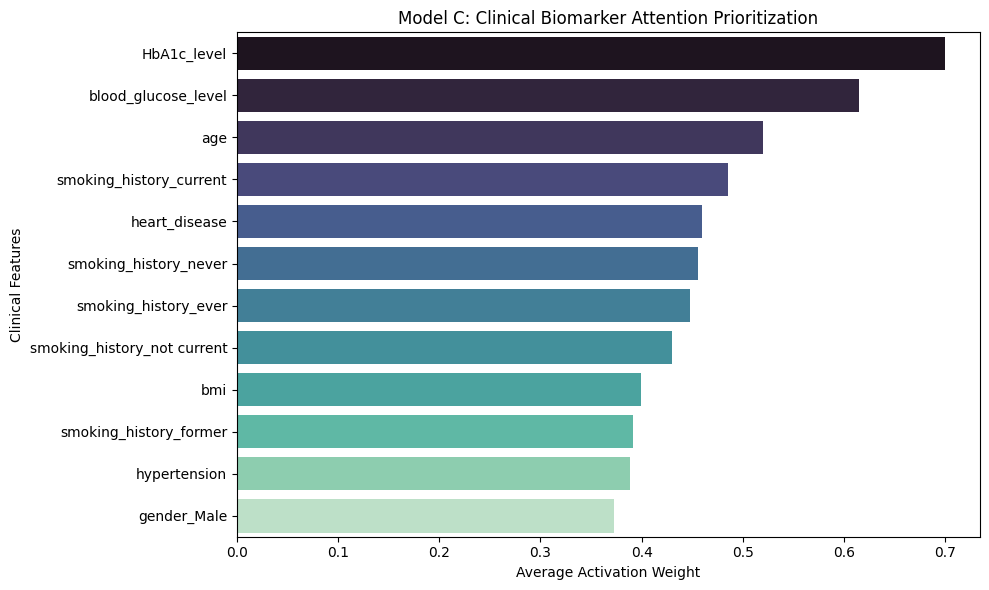

In [8]:
# =====================================================================
#   ATTENTION WEIGHT INTERPRETABILITY ANALYSIS
# =====================================================================
def plot_clinical_attention(model, test_loader, feature_names):
    model.eval()
    all_weights = []

    with torch.no_grad():
        for batch_features, _ in test_loader:
            _, weights = model(batch_features, return_attention=True)
            all_weights.append(weights.cpu().numpy())

    avg_weights = np.mean(np.vstack(all_weights), axis=0)

    sorted_idx = np.argsort(avg_weights)[::-1]
    sorted_weights = avg_weights[sorted_idx]
    sorted_features = [feature_names[i] for i in sorted_idx]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_weights, y=sorted_features, palette="mako")
    plt.title("Model C: Clinical Biomarker Attention Prioritization")
    plt.xlabel("Average Activation Weight")
    plt.ylabel("Clinical Features")
    plt.tight_layout()
    plt.show()

feature_names = [
    'age', 'hypertension', 'heart_disease', 'bmi',
    'HbA1c_level', 'blood_glucose_level', 'gender_Male',
    'smoking_history_current', 'smoking_history_ever',
    'smoking_history_former', 'smoking_history_never',
    'smoking_history_not current'
]

plot_clinical_attention(model_c, test_loader, feature_names)

Default (0.5) Threshold - Precision: 0.458 | Recall: 0.916
Optimal (0.6672) Threshold - Precision: 0.956 | Recall: 0.687


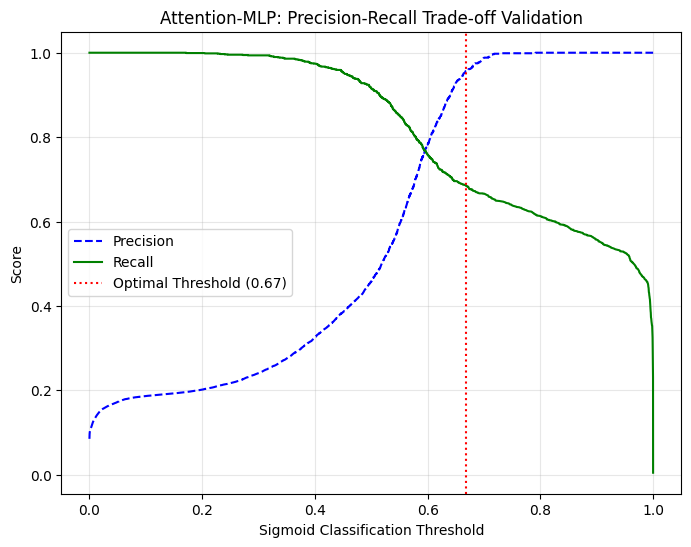

In [9]:
from sklearn.metrics import precision_recall_curve

# =====================================================================
#  THRESHOLD OPTIMIZATION & PR CURVE
# =====================================================================
def optimize_model_threshold(model, test_loader):
    model.eval()
    y_true = []
    y_probs = []

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            outputs = model(batch_features)
            y_probs.extend(outputs.cpu().numpy().flatten())
            y_true.extend(batch_labels.cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"Default (0.5) Threshold - Precision: {precisions[np.abs(thresholds - 0.5).argmin()]:.3f} | Recall: {recalls[np.abs(thresholds - 0.5).argmin()]:.3f}")
    print(f"Optimal ({optimal_threshold:.4f}) Threshold - Precision: {precisions[optimal_idx]:.3f} | Recall: {recalls[optimal_idx]:.3f}")

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.axvline(x=optimal_threshold, color='r', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')

    plt.xlabel('Sigmoid Classification Threshold')
    plt.ylabel('Score')
    plt.title('Attention-MLP: Precision-Recall Trade-off Validation')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()


optimize_model_threshold(model_c, test_loader)

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =====================================================================
#  EXTRACTING RAW TRAINING DATA FOR K-FOLD
# =====================================================================

raw_df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')
raw_df = raw_df[raw_df['gender'] != 'Other']
raw_df = pd.get_dummies(raw_df, columns=['gender', 'smoking_history'], drop_first=True)

X_raw_df = raw_df.drop('diabetes', axis=1)
y_raw_numpy = raw_df['diabetes'].values

scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw_df)

X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_raw_scaled, y_raw_numpy, test_size=0.30, random_state=42, stratify=y_raw_numpy
)

print(f"Recovered Pre-SMOTE Training Features: {X_train_raw.shape} (Should be ~69k rows, 12 cols)")
print(f"Recovered Pre-SMOTE Training Labels: {y_train_raw.shape}")

Recovered Pre-SMOTE Training Features: (69987, 12) (Should be ~69k rows, 12 cols)
Recovered Pre-SMOTE Training Labels: (69987,)


In [12]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
import time
import psutil
from sklearn.metrics import recall_score
from torch.utils.data import TensorDataset, DataLoader

# =====================================================================
#  K-FOLD CROSS-VALIDATION & EFFICIENCY BENCHMARKING
# =====================================================================

def run_robustness_benchmark(X_raw, y_raw, num_folds=5, epochs=30):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    metrics = {'recall': [], 'time': [], 'memory': []}

    print(f"Starting {num_folds}-Fold Robustness Validation for Attention-MLP...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y_raw)):
        print(f"\n--- Fold {fold + 1}/{num_folds} ---")

        X_train_fold, X_val_fold = X_raw[train_idx], X_raw[val_idx]
        y_train_fold, y_val_fold = y_raw[train_idx], y_raw[val_idx]

        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train_fold, y_train_fold)

        train_tensor = TensorDataset(torch.FloatTensor(X_train_smote), torch.FloatTensor(y_train_smote).view(-1, 1))
        val_tensor = TensorDataset(torch.FloatTensor(X_val_fold), torch.FloatTensor(y_val_fold).view(-1, 1))

        fold_train_loader = DataLoader(train_tensor, batch_size=256, shuffle=True)
        fold_val_loader = DataLoader(val_tensor, batch_size=512, shuffle=False)

        model = AttentionMLP(input_dim=12)
        criterion = FocalLoss(alpha=0.25, gamma=2.0)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        start_time = time.time()

        for epoch in range(epochs):
            model.train()
            for batch_x, batch_y in fold_train_loader:
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        exec_time = time.time() - start_time
        peak_memory = psutil.Process().memory_info().rss / (1024 * 1024)

        model.eval()
        fold_preds, fold_targets = [], []
        with torch.no_grad():
            for batch_x, batch_y in fold_val_loader:
                outputs = model(batch_x)
                fold_preds.extend((outputs >= 0.5).float().numpy())
                fold_targets.extend(batch_y.numpy())

        fold_recall = recall_score(fold_targets, fold_preds)

        metrics['recall'].append(fold_recall)
        metrics['time'].append(exec_time)
        metrics['memory'].append(peak_memory)

        print(f"Fold {fold+1} Recall: {fold_recall:.4f} | Time: {exec_time:.1f}s | Mem: {peak_memory:.1f}MB")

    print("\n================ FINAL ROBUSTNESS RESULTS ================")
    print(f"Mean Minority Recall: {np.mean(metrics['recall'])*100:.2f}% ± {np.std(metrics['recall'])*100:.2f}%")
    print(f"Average Training Time: {np.mean(metrics['time']):.2f} seconds")
    print(f"Peak Memory Footprint: {np.max(metrics['memory']):.2f} MB")

# Execute benchmark
run_robustness_benchmark(X_train_raw, y_train_raw)

Starting 5-Fold Robustness Validation for Attention-MLP...

--- Fold 1/5 ---
Fold 1 Recall: 0.9109 | Time: 74.1s | Mem: 685.4MB

--- Fold 2/5 ---
Fold 2 Recall: 0.8908 | Time: 75.1s | Mem: 698.7MB

--- Fold 3/5 ---
Fold 3 Recall: 0.9084 | Time: 73.1s | Mem: 694.1MB

--- Fold 4/5 ---
Fold 4 Recall: 0.9143 | Time: 76.6s | Mem: 682.1MB

--- Fold 5/5 ---
Fold 5 Recall: 0.9143 | Time: 74.3s | Mem: 704.3MB

================ FINAL ROBUSTNESS RESULTS ================
Mean Minority Recall: 90.77% ± 0.88%
Average Training Time: 74.63 seconds
Peak Memory Footprint: 704.33 MB
